Using Colab cache for faster access to the 'potato-plant-diseases-data' dataset.
Dataset Path: /kaggle/input/potato-plant-diseases-data
Total Images: 2152


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 36s 651ms/step - accuracy: 0.5869 - loss: 0.9171 - val_accuracy: 0.7425 - val_loss: 0.6253
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 35s 649ms/step - accuracy: 0.7885 - loss: 0.5726 - val_accuracy: 0.8608 - val_loss: 0.4087
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 35s 646ms/step - accuracy: 0.8425 - loss: 0.4175 - val_accuracy: 0.8701 - val_loss: 0.2955
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 35s 641ms/step - accuracy: 0.8501 - loss: 0.3626 - val_accuracy: 0.8770 - val_loss: 0.2698
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 35s 647ms/step - accuracy: 0.8809 - loss: 0.2904 - val_accuracy: 0.9466 - val_loss: 0.1713
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 35s 647ms/step - accuracy: 0.8873 - loss: 0.2833 - val_accuracy: 0.9327 - val_loss: 0.2148
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 35s 652ms/step - accuracy: 0.9001 - loss: 0.2786 - val_accuracy: 0.8840 - val_loss: 0.3068
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 35s 642ms/step - accuracy: 0.9326 - loss: 0.1854 - val_accu

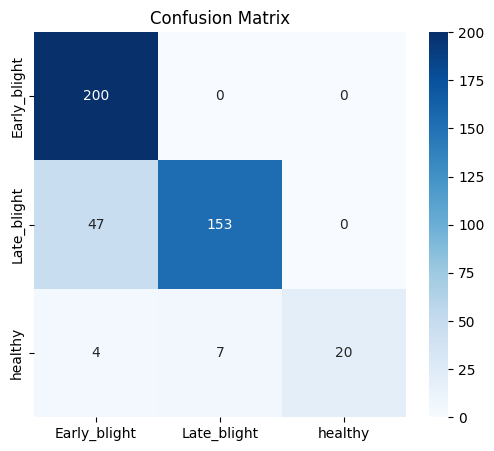

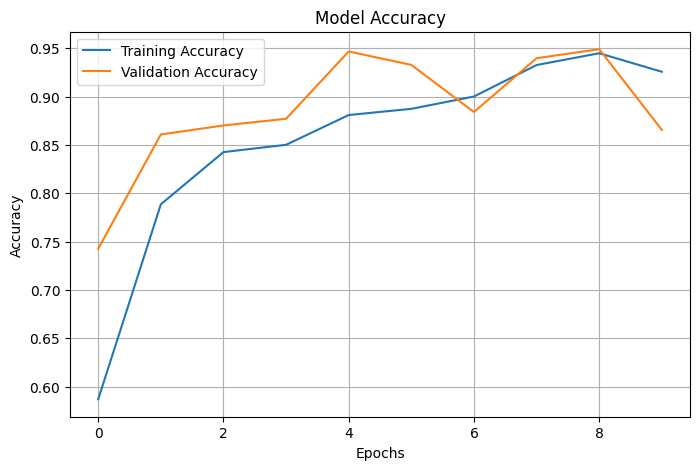

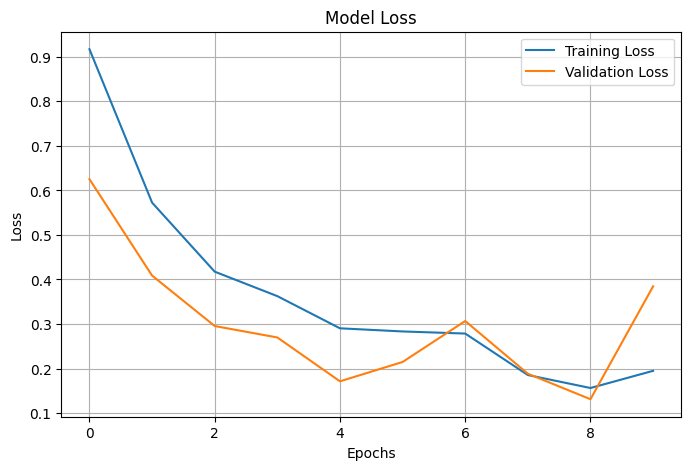


Classification Report:

              precision    recall  f1-score   support

Early Blight       0.80      1.00      0.89       200
 Late Blight       0.96      0.77      0.85       200
     Healthy       1.00      0.65      0.78        31

    accuracy                           0.87       431
   macro avg       0.92      0.80      0.84       431
weighted avg       0.89      0.87      0.86       431



In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input

from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import kagglehub

path = kagglehub.dataset_download("hafiznouman786/potato-plant-diseases-data")

print("Dataset Path:", path)

classes = ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
image_size = 128

X = []
y = []

base_image_dir = os.path.join(path, 'PlantVillage', 'PlantVillage')

for label, category in enumerate(classes):
    folder_path = os.path.join(base_image_dir, category)
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        try:
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (image_size, image_size))
            img = img / 255.0
            X.append(img)
            y.append(label)
        except Exception as e:
            print(f"Error loading image: {img_path}. Details: {e}")

X = np.array(X)
y = np.array(y)

print("Total Images:", len(X))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

y_train = to_categorical(y_train, num_classes=3)
y_test = to_categorical(y_test, num_classes=3)

datagen = ImageDataGenerator(
    rotation_range=20, zoom_range=0.2, horizontal_flip=True, vertical_flip=True
)
datagen.fit(X_train)

model = Sequential([
    Input(shape=(128, 128, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(X_test, y_test)
)

loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_true, y_pred_classes), annot=True, fmt='d', cmap='Blues',
            xticklabels=[c.replace('Potato___', '') for c in classes],
            yticklabels=[c.replace('Potato___', '') for c in classes])
plt.title("Confusion Matrix")
plt.show()
# -----------------------------
# Accuracy Graph
# -----------------------------
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()


# -----------------------------
# Loss Graph
# -----------------------------
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()


# -----------------------------
# Classification Report
# -----------------------------
print("\nClassification Report:\n")

target_names = ['Early Blight', 'Late Blight', 'Healthy']

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=target_names
))

Saving Screenshot 2026-05-18 182535.png to Screenshot 2026-05-18 182535 (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


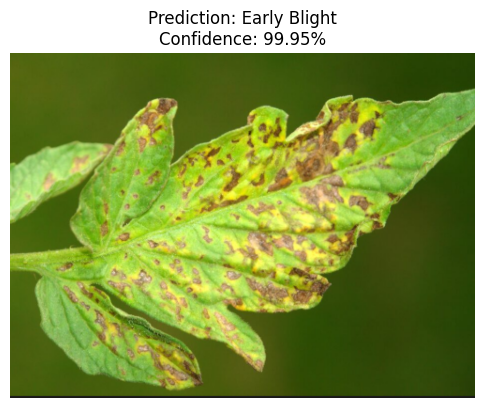

Predicted Disease: Early Blight
Confidence: 99.95321


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ---------------------------------
# Upload Image
# ---------------------------------

uploaded = files.upload()

# Get uploaded file name
image_path = list(uploaded.keys())[0]

# ---------------------------------
# Read Image
# ---------------------------------

img = cv2.imread(image_path)

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize image
img_resized = cv2.resize(img_rgb, (128, 128))

# Normalize
img_resized = img_resized / 255.0

# Add batch dimension
input_image = np.expand_dims(img_resized, axis=0)

# ---------------------------------
# Predict Disease
# ---------------------------------

prediction = model.predict(input_image)

class_names = ['Early Blight', 'Late Blight', 'Healthy']

predicted_class = np.argmax(prediction)

confidence = np.max(prediction) * 100

# ---------------------------------
# Show Result
# ---------------------------------

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title(f"Prediction: {class_names[predicted_class]}\nConfidence: {confidence:.2f}%")
plt.axis('off')
plt.show()

print("Predicted Disease:", class_names[predicted_class])
print("Confidence:", confidence)